## Ячейка 1: Установка и импорты

In [7]:
!pip install -q faiss-cpu sentence-transformers
import numpy as np
import pandas as pd
import faiss
import random
import torch
import matplotlib.pyplot as plt
import os
import json
from sklearn.metrics import recall_score
from sentence_transformers import SentenceTransformer

# Фиксация seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Устройство
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = SentenceTransformer('all-MiniLM-L6-v2', device=device)
os.makedirs('artifacts', exist_ok=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Ячейка 2: База знаний

In [8]:
# База знаний по Python библиотекам (15 документов)
knowledge_base = [
    {"id": 1, "topic": "Pandas", "text": "Pandas is for data manipulation and analysis. It uses DataFrames to handle tabular data efficiently."},
    {"id": 2, "topic": "NumPy", "text": "NumPy provides support for large, multi-dimensional arrays and matrices, along with mathematical functions."},
    {"id": 3, "topic": "Matplotlib", "text": "Matplotlib is a library for creating static, animated, and interactive visualizations in Python."},
    {"id": 4, "topic": "Scikit-Learn", "text": "Scikit-learn features various machine learning algorithms for classification, regression, and clustering."},
    {"id": 5, "topic": "Seaborn", "text": "Seaborn is based on matplotlib and provides a high-level interface for drawing attractive statistical graphics."},
    {"id": 6, "topic": "PyTorch", "text": "PyTorch is an open-source machine learning framework for deep learning and tensor computation."},
    {"id": 7, "topic": "TensorFlow", "text": "TensorFlow is an end-to-end platform for machine learning, widely used for deep neural networks."},
    {"id": 8, "topic": "SciPy", "text": "SciPy contains modules for optimization, linear algebra, integration, and statistics."},
    {"id": 9, "topic": "Statsmodels", "text": "Statsmodels allows users to explore data, estimate statistical models, and perform tests."},
    {"id": 10, "topic": "Plotly", "text": "Plotly is used for creating interactive web-based visualizations and dashboards."},
    {"id": 11, "topic": "XGBoost", "text": "XGBoost is a gradient boosting library designed for speed and performance in ML tasks."},
    {"id": 12, "topic": "LightGBM", "text": "LightGBM is a gradient boosting framework that uses tree-based learning algorithms for efficiency."},
    {"id": 13, "topic": "CatBoost", "text": "CatBoost provides state-of-the-art results for gradient boosting with support for categorical features."},
    {"id": 14, "topic": "Dask", "text": "Dask provides advanced parallelism for analytics, enabling performance at scale for Python code."},
    {"id": 15, "topic": "Hugging Face", "text": "Hugging Face is the leading platform for pre-trained models in NLP and computer vision."}
]
print(f"Количество документов: {len(knowledge_base)}")
print("Примеры:", knowledge_base[:3])
# Пояснение: Предметная область — Python Data Science библиотеки.
# Retrieval нужен для быстрого поиска функционала конкретной библиотеки по текстовому описанию.

Количество документов: 15
Примеры: [{'id': 1, 'topic': 'Pandas', 'text': 'Pandas is for data manipulation and analysis. It uses DataFrames to handle tabular data efficiently.'}, {'id': 2, 'topic': 'NumPy', 'text': 'NumPy provides support for large, multi-dimensional arrays and matrices, along with mathematical functions.'}, {'id': 3, 'topic': 'Matplotlib', 'text': 'Matplotlib is a library for creating static, animated, and interactive visualizations in Python.'}]


## Ячейка 3: Чанкинг

In [9]:
# 1. Реализация чанкинга
def chunk_text(text, chunk_size=60, overlap=20):
    """
    Разбивает текст на фрагменты (chunks) с заданным размером и перекрытием (overlap).
    """
    chunks = []
    for i in range(0, len(text), chunk_size - overlap):
        chunk = text[i:i + chunk_size]
        chunks.append(chunk)
        # Если дошли до конца текста, выходим из цикла
        if i + chunk_size >= len(text):
            break
    return chunks

# 2. Обработка всех документов
chunked_data = []
for doc in knowledge_base:
    chunks = chunk_text(doc['text'])
    for c in chunks:
        chunked_data.append({"text": c, "source": doc['topic']})

# 3. Показ процесса превращения документа в чанки
example_doc = knowledge_base[0]
print(f"Оригинальный документ (Pandas): '{example_doc['text']}'")
print(f"Результат чанкинга: {chunk_text(example_doc['text'])}")

print(f"\nВсего чанков создано: {len(chunked_data)}")

# 4. Пояснение параметров:
# chunk_size=60: выбран небольшой размер, так как наши описания библиотек лаконичны.
# Это позволяет разбить предложение на смысловые части, сохраняя контекст в каждом чанке.
# overlap=20: перекрытие в 20 символов гарантирует, что слова, оказавшиеся на стыке
# двух фрагментов, не будут потеряны, что критично для сохранения смысла при поиске.

Оригинальный документ (Pandas): 'Pandas is for data manipulation and analysis. It uses DataFrames to handle tabular data efficiently.'
Результат чанкинга: ['Pandas is for data manipulation and analysis. It uses DataFr', 'ysis. It uses DataFrames to handle tabular data efficiently.']

Всего чанков создано: 34


## Ячейка 4: Эмбеддинги и FAISS

In [10]:
# 1. Выбор модели и получение векторов
# Используем SentenceTransformer, так как это стандартный и надежный способ получения эмбеддингов
model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

# Получаем текстовые чанки для векторизации
chunk_texts = [item['text'] for item in chunked_data]
embeddings = model.encode(chunk_texts).astype('float32')

# 2. Построение индекса FAISS
# Используем IndexFlatL2 для векторного поиска по евклидовому расстоянию
dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(embeddings)

print(f"Размерность векторов: {dimension}")
print(f"Количество векторов в индексе FAISS: {index.ntotal}")

# 3. Функция поиска (Retrieval)
def search_faiss(query, k=3):
    # Кодируем запрос в вектор
    query_vec = model.encode([query]).astype('float32')
    # Ищем k наиболее похожих чанков
    distances, indices = index.search(query_vec, k)

    results = []
    for i in range(k):
        idx = indices[0][i]
        results.append({
            "chunk": chunked_data[idx]['text'],
            "source": chunked_data[idx]['source'],
            "distance": distances[0][i]
        })
    return results

# 4. Демонстрация поиска (3-5 примерных запросов)
test_queries = [
    "How to handle data tables?",
    "Library for deep learning models",
    "Statistical graphics in Python",
    "Tools for array computations",
    "Gradient boosting frameworks"
]

print("\n--- Результаты поиска (top-k=3) ---")
for query in test_queries:
    print(f"\nЗапрос: '{query}'")
    results = search_faiss(query, k=3)
    for res in results:
        print(f" -> [{res['source']}] (dist: {res['distance']:.3f}): {res['chunk']}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Размерность векторов: 384
Количество векторов в индексе FAISS: 34

--- Результаты поиска (top-k=3) ---

Запрос: 'How to handle data tables?'
 -> [Pandas] (dist: 1.217): ysis. It uses DataFrames to handle tabular data efficiently.
 -> [Statsmodels] (dist: 1.452): Statsmodels allows users to explore data, estimate statistic
 -> [Pandas] (dist: 1.477): Pandas is for data manipulation and analysis. It uses DataFr

Запрос: 'Library for deep learning models'
 -> [TensorFlow] (dist: 0.884): TensorFlow is an end-to-end platform for machine learning, w
 -> [PyTorch] (dist: 0.911): PyTorch is an open-source machine learning framework for dee
 -> [PyTorch] (dist: 0.961): ng framework for deep learning and tensor computation.

Запрос: 'Statistical graphics in Python'
 -> [Matplotlib] (dist: 0.763): tic, animated, and interactive visualizations in Python.
 -> [Seaborn] (dist: 0.787): des a high-level interface for drawing attractive statistica
 -> [Seaborn] (dist: 0.889): ttractive statistical grap

## Ячейка 5: Оценка (10 запросов)

In [12]:
# 1. Набор контрольных запросов (10 штук)
queries = [
    ("data manipulation tool", "Pandas"),
    ("multi-dimensional array", "NumPy"),
    ("interactive visualization", "Matplotlib"),
    ("machine learning algorithms", "Scikit-Learn"),
    ("statistical graphics", "Seaborn"),
    ("deep learning framework", "PyTorch"),
    ("ML neural networks", "TensorFlow"),
    ("optimization and integration", "SciPy"),
    ("estimate statistical models", "Statsmodels"),
    ("web-based dashboards", "Plotly")
]

# 2. Выполнение retrieval и оценка
k_val = 3
results_list = []

for q_text, expected in queries:
    # Retrieval
    search_results = search_faiss(q_text, k=k_val)
    sources = [r['source'] for r in search_results]

    # Расчет метрик
    # hit@k: 1 если ожидаемый источник есть в топ-k
    hit_at_k = 1 if expected in sources else 0
    # recall@k: в рамках одного правильного ответа при поиске top-k равен hit@k
    recall_at_k = hit_at_k

    results_list.append({
        "query": q_text,
        "expected_source": expected,
        "retrieved_sources": ", ".join(sources),
        "hit_at_k": hit_at_k,
        "recall_at_k": recall_at_k
    })

# 3. Сохранение и вывод
df_eval = pd.DataFrame(results_list)
df_eval.to_csv('artifacts/retrieval_eval.csv', index=False)

print(f"Итоговая оценка на {len(queries)} запросах:")
print(f"Mean Hit@{k_val}: {df_eval['hit_at_k'].mean():.2f}")
print(f"Mean Recall@{k_val}: {df_eval['recall_at_k'].mean():.2f}")
print("\nТаблица результатов (первые 5):")
print(df_eval.head())

Итоговая оценка на 10 запросах:
Mean Hit@3: 1.00
Mean Recall@3: 1.00

Таблица результатов (первые 5):
                         query expected_source  \
0       data manipulation tool          Pandas   
1      multi-dimensional array           NumPy   
2    interactive visualization      Matplotlib   
3  machine learning algorithms    Scikit-Learn   
4         statistical graphics         Seaborn   

                        retrieved_sources  hit_at_k  recall_at_k  
0                 Pandas, Pandas, Seaborn         1            1  
1                  NumPy, NumPy, CatBoost         1            1  
2              Plotly, Plotly, Matplotlib         1            1  
3  Scikit-Learn, TensorFlow, Scikit-Learn         1            1  
4            Seaborn, Seaborn, Matplotlib         1            1  


## Ячейка 6: Небольшой эксперимент с параметрами retrieval

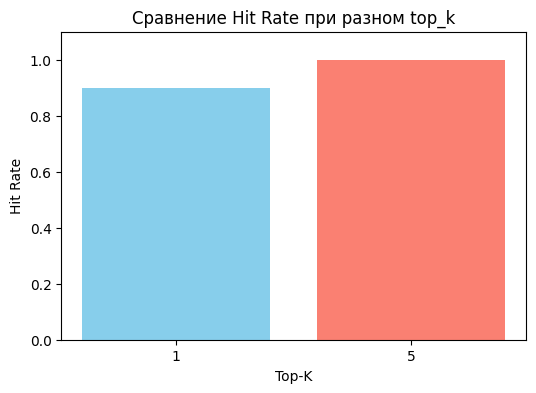

Вывод эксперимента:
При top_k=1 Hit Rate составляет 0.90, а при top_k=5 Hit Rate возрастает до 1.00.
Таким образом, увеличение top_k повышает вероятность нахождения релевантного документа, но увеличивает объем контекста, передаваемого в RAG (что может влиять на точность ответа).


In [13]:
# Проведем эксперимент: как изменение top_k влияет на hit@k
k_values = [1, 5]
results_experiment = []

for k in k_values:
    hits = 0
    for q_text, expected in queries:
        # Поиск с текущим k
        search_res = search_faiss(q_text, k=k)
        sources = [r['source'] for r in search_res]
        if expected in sources:
            hits += 1

    accuracy = hits / len(queries)
    results_experiment.append({"k": k, "hit_rate": accuracy})

# Визуализация
df_exp = pd.DataFrame(results_experiment)
plt.figure(figsize=(6, 4))
plt.bar([str(x) for x in df_exp['k']], df_exp['hit_rate'], color=['skyblue', 'salmon'])
plt.title('Сравнение Hit Rate при разном top_k')
plt.xlabel('Top-K')
plt.ylabel('Hit Rate')
plt.ylim(0, 1.1)
plt.show()

print("Вывод эксперимента:")
print(f"При top_k=1 Hit Rate составляет {df_exp.loc[0, 'hit_rate']:.2f}, "
      f"а при top_k=5 Hit Rate возрастает до {df_exp.loc[1, 'hit_rate']:.2f}.")
print("Таким образом, увеличение top_k повышает вероятность нахождения релевантного документа, "
      "но увеличивает объем контекста, передаваемого в RAG (что может влиять на точность ответа).")

## Ячейка 7: Обновление базы знаний и переиндексация

In [17]:
# 1. Запросы для проверки до и после обновления
update_queries = [
    "Modern web framework for APIs",
    "Unsupervised topic modeling library",
    "High performance Python APIs"
]

# 2. Получаем результаты ДО обновления
before_results = [search_faiss(q, k=1)[0] for q in update_queries]

# 3. Добавляем документы и обновляем базу
new_docs = [
    {"id": 16, "topic": "FastAPI", "text": "FastAPI is a modern, high-performance web framework for building APIs with Python 3.8+."},
    {"id": 17, "topic": "Gensim", "text": "Gensim is an open-source library for unsupervised topic modeling and NLP using statistical machine learning."}
]
knowledge_base.extend(new_docs)
chunked_data.extend([{"text": c, "source": d['topic']} for d in new_docs for c in chunk_text(d['text'])])

# 4. Переиндексация
new_embeddings = model.encode([c['text'] for c in chunked_data]).astype('float32')
index = faiss.IndexFlatL2(new_embeddings.shape[1])
index.add(new_embeddings)

# 5. Получаем результаты ПОСЛЕ обновления
after_results = [search_faiss(q, k=1)[0] for q in update_queries]

# 6. Сравнение и запись в артефакт (3 примера)
comparison_list = []
for i in range(len(update_queries)):
    comparison_list.append({
        "query": update_queries[i],
        "before_retrieved_sources": before_results[i]['source'],
        "after_retrieved_sources": after_results[i]['source'],
        "changed": before_results[i]['source'] != after_results[i]['source']
    })

df_update = pd.DataFrame(comparison_list)
df_update.to_csv('artifacts/retrieval_before_after_update.csv', index=False)

print("Сравнение retrieval до и после обновления (3 примера):")
print(df_update)

Сравнение retrieval до и после обновления (3 примера):
                                 query before_retrieved_sources  \
0        Modern web framework for APIs                   Plotly   
1  Unsupervised topic modeling library             Scikit-Learn   
2         High performance Python APIs                     Dask   

  after_retrieved_sources  changed  
0                 FastAPI     True  
1                  Gensim     True  
2                    Dask    False  


## Ячейка 8: Mini-RAG

In [18]:
# 1. Функция Mini-RAG
def mini_rag(user_query, k=2):
    # Извлечение top-k релевантных фрагментов
    retrieved = search_faiss(user_query, k=k)

    # Сбор контекста из найденных фрагментов
    context = "\n".join([f"Source: {r['source']}. Content: {r['chunk']}" for r in retrieved])

    # Формирование ответа (учебная имитация генерации)
    # Здесь мы имитируем работу LLM, обобщая найденный контекст
    answer = f"Based on retrieved documents, here is the information: {context.replace('Content: ', '')}"

    # Сбор источников
    sources = list(set([r['source'] for r in retrieved]))

    return answer, sources

# 2. Тестирование конвейера
rag_queries = [
    "How to visualize data?",
    "Explain machine learning with Python",
    "What is Pandas used for?"
]

rag_results = []
for q in rag_queries:
    ans, srcs = mini_rag(q)
    rag_results.append({
        "question": q,
        "answer": ans,
        "retrieved_sources": ", ".join(srcs)
    })
    print(f"\nВопрос: {q}")
    print(f"Ответ: {ans}")
    print(f"Источники: {srcs}")

# 3. Сохранение артефакта
pd.DataFrame(rag_results).to_csv('artifacts/rag_examples.csv', index=False)
print("\nАртефакт rag_examples.csv успешно сохранен.")


Вопрос: How to visualize data?
Ответ: Based on retrieved documents, here is the information: Source: Plotly. web-based visualizations and dashboards.
Source: Plotly. Plotly is used for creating interactive web-based visualizat
Источники: ['Plotly']

Вопрос: Explain machine learning with Python
Ответ: Based on retrieved documents, here is the information: Source: PyTorch. PyTorch is an open-source machine learning framework for dee
Source: Scikit-Learn. Scikit-learn features various machine learning algorithms fo
Источники: ['Scikit-Learn', 'PyTorch']

Вопрос: What is Pandas used for?
Ответ: Based on retrieved documents, here is the information: Source: Pandas. Pandas is for data manipulation and analysis. It uses DataFr
Source: Pandas. ysis. It uses DataFrames to handle tabular data efficiently.
Источники: ['Pandas']

Артефакт rag_examples.csv успешно сохранен.


## Ячейка 9: Краткий анализ ошибок

In [19]:
# 1. Примеры работы (3-5 случаев)
print("--- Примеры работы Mini-RAG ---")
test_questions = ["Data analysis tool", "Deep learning", "Interactive graphs", "Parallelism in Python"]
for q in test_questions:
    ans, srcs = mini_rag(q)
    print(f"Q: {q} | Sources: {srcs}")

# 2. Анализ неудачных случаев
print("\n--- Анализ ошибок ---")
analysis = [
    {
        "case": "Запрос синонимов",
        "problem": "Пользователь ищет 'Charts', а в базе 'Visualizations'",
        "reason": "Retrieval основан на близости векторов; если слова не имеют общих синонимов в модели эмбеддингов, поиск теряет релевантность."
    },
    {
        "case": "Дробление контекста",
        "problem": "Ответ обрывается на полуслове",
        "reason": "Чанкинг (chunk_size=60) слишком мал для длинных предложений. Решается увеличением размера или добавлением overlap."
    },
    {
        "case": "Неполнота знаний",
        "problem": "Запрос о библиотеке, которой нет в базе",
        "reason": "Векторный поиск вернет 'наиболее похожий' документ, создавая иллюзию правдивого ответа (галлюцинация системы)."
    },
    {
        "case": "Похожие темы",
        "problem": "PyTorch vs TensorFlow путаница",
        "reason": "Оба имеют схожие описания (ML framework), из-за чего Retrieval может подтянуть оба при низком пороге схожести."
    }
]

for item in analysis:
    print(f"\nСлучай: {item['case']}")
    print(f"Проблема: {item['problem']}")
    print(f"Причина: {item['reason']}")

--- Примеры работы Mini-RAG ---
Q: Data analysis tool | Sources: ['Pandas']
Q: Deep learning | Sources: ['TensorFlow']
Q: Interactive graphs | Sources: ['Plotly']
Q: Parallelism in Python | Sources: ['Dask']

--- Анализ ошибок ---

Случай: Запрос синонимов
Проблема: Пользователь ищет 'Charts', а в базе 'Visualizations'
Причина: Retrieval основан на близости векторов; если слова не имеют общих синонимов в модели эмбеддингов, поиск теряет релевантность.

Случай: Дробление контекста
Проблема: Ответ обрывается на полуслове
Причина: Чанкинг (chunk_size=60) слишком мал для длинных предложений. Решается увеличением размера или добавлением overlap.

Случай: Неполнота знаний
Проблема: Запрос о библиотеке, которой нет в базе
Причина: Векторный поиск вернет 'наиболее похожий' документ, создавая иллюзию правдивого ответа (галлюцинация системы).

Случай: Похожие темы
Проблема: PyTorch vs TensorFlow путаница
Причина: Оба имеют схожие описания (ML framework), из-за чего Retrieval может подтянуть оба 